# Human Action Classifier
**Schuldt et al. 2004. Recognizing Human Actions: A Local SVM Approach**

In [3]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import re
import csv

from pathlib import Path
from collections import Counter
from sklearn.cluster import MiniBatchKMeans
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from joblib import dump

In [ ]:
# NVIDIA cuda
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### 1. Data Loading

In [5]:
PREFIX = "0228-"
DESCRIPTION = "With Video Transformation (Horizontal Flip) and Empty Scene"
K = 800
ACTIONS = ["boxing", "handclapping", "handwaving", "jogging", "running", "walking", "empty"]
action_to_id = {a: i for i, a in enumerate(ACTIONS)}

VIDEO_ID_PATTERN = re.compile(r"person(?P<person>\d+)_(?P<action>[a-z]+)_d(?P<scene>\d+)")

def index_data(csv_file="data/info.csv", clips_root="data/transform"):
    samples = []

    with open(csv_file, newline="") as f:
        reader = csv.DictReader(f)

        for row in reader:
            video_id = row["video_id"]
            target_video = row["target_video"]
            action = row["label"]

            match = VIDEO_ID_PATTERN.match(video_id)
            if match is None or action not in action_to_id:
                continue

            clip_path = Path(clips_root) / target_video
            if not clip_path.exists():
                continue    # Skip missing clips (safe for partial generation)

            samples.append({
                "path": clip_path,
                "label": action_to_id[action],
                "action": action,
                "person": int(match.group("person")),
                "scene": int(match.group("scene")),
                "segment_id": int(row["segment_id"]),
                "video_id": video_id,
                "start_frame": int(row["start_frame"]),
                "end_frame": int(row["end_frame"]),
            })

    return samples

In [6]:
# Import all data
samples = index_data()
print("Total:", Counter(s["action"] for s in samples))

# Train/validation/test split (70-15-15)
train_samples = [s for s in samples if s["person"] <= 17]
val_samples = [s for s in samples if 17 < s["person"] <= 21]
test_samples = [s for s in samples if s["person"] > 21]
print("Train:", len(train_samples), "Validation:", len(val_samples), "Test:", len(test_samples))

Total: Counter({'jogging': 800, 'running': 800, 'walking': 800, 'empty': 800, 'handwaving': 796, 'boxing': 794, 'handclapping': 792})
Train: 3778 Validation: 904 Test: 900


### 2. Data Processing
#### 2.1. Transform Video To Image Sequence

In [7]:
def load_video(path, resize=(160, 120)):
    cap = cv2.VideoCapture(str(path))
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame = cv2.resize(frame, resize)
        frame = frame.astype(np.float32) / 255.0
        frames.append(frame)

    cap.release()
    video = np.stack(frames)   # (T, H, W)
    return torch.from_numpy(video)

#### 2.2. Construct Gaussian Scale Space
$$L(· , \sigma^2, \tau^2) = f \times g(· , \sigma^2, \tau^2)$$

In [8]:
def gaussian_1d(kernel_size, sigma):
    x = torch.arange(kernel_size) - kernel_size // 2
    g = torch.exp(-(x ** 2) / (2 * (sigma ** 2)))
    return g / g.sum()

def gaussian_blur_3d(video, sigma, tau):
    # spatial blur
    g_xy = gaussian_1d(7, sigma)
    g_xy = g_xy[None, None, :, None] * g_xy[None, None, None, :]
    g_xy = g_xy.to(video.device)
    video = F.conv2d(video.unsqueeze(1), g_xy, padding=3).squeeze(1)

    # temporal blur
    g_t = gaussian_1d(7, tau)[None, None, :, None, None]
    g_t = g_t.to(video.device)
    video = F.conv3d(video.unsqueeze(0), g_t, padding=(3,0,0)).squeeze(0)

    return video

### 3. Feature Extraction
#### 3.1. Compute Second-moment Matrix From Spatio-temporal Gradients

$$\nabla L = (L_x, L_y, L_t)^T$$
$$\mu(·; \sigma^2, \tau^2) = g(·; s\sigma^2, s\tau^2) \times (\nabla L(\nabla L)^T)$$

In [9]:
def gradients_3d(L):
	Lx = L[:, :, 2:] - L[:, :, :-2]
	Ly = L[:, 2:, :] - L[:, :-2, :]
	Lt = L[2:, :, :] - L[:-2, :, :]

	T = min(Lx.shape[0], Ly.shape[0], Lt.shape[0])
	H = min(Lx.shape[1], Ly.shape[1], Lt.shape[1])
	W = min(Lx.shape[2], Ly.shape[2], Lt.shape[2])

	return Lx[:T, :H, :W], Ly[:T, :H, :W], Lt[:T, :H, :W]

def second_moment_matrix(Lx, Ly, Lt, sigma=2.0, tau=1.5):
    J_xx = Lx * Lx
    J_xy = Lx * Ly
    J_xt = Lx * Lt
    J_yy = Ly * Ly
    J_yt = Ly * Lt
    J_tt = Lt * Lt

    def smooth(x):
        return gaussian_blur_3d(x, sigma, tau)

    return smooth(J_xx), smooth(J_xy), smooth(J_xt), smooth(J_yy), smooth(J_yt), smooth(J_tt)

#### 3.2. Detect Interest Point Using Harris Response

$$H = det(\mu) - k * trace^3(\mu)$$

In [10]:
def harris_response(J, k=0.005):
    J_xx, J_xy, J_xt, J_yy, J_yt, J_tt = J

    det = (
        J_xx * (J_yy * J_tt - J_yt ** 2)
        - J_xy * (J_xy * J_tt - J_xt * J_yt)
        + J_xt * (J_xy * J_yt - J_xt * J_yy)
    )

    trace = J_xx + J_yy + J_tt
    return det - k * trace ** 3

def detect_interest_points(H, threshold_ratio=0.01):
    threshold = threshold_ratio * H.max()
    points = torch.nonzero(H > threshold)
    return points

#### 3.3. Extract Spatio-temporal Descriptors

$$\bold{l} = (L_x, L_y, L_t, L_{xx}, ..., L_{tttt})$$

In [11]:
def extract_jet(L, x, y, t):
    Lc = L[t, y, x]

    # first order
    Lx  = L[t, y, x+1] - L[t, y, x-1]
    Ly  = L[t, y+1, x] - L[t, y-1, x]
    Lt  = L[t+1, y, x] - L[t-1, y, x]

    # second order
    Lxx = L[t, y, x+1] - 2*Lc + L[t, y, x-1]
    Lyy = L[t, y+1, x] - 2*Lc + L[t, y-1, x]
    Ltt = L[t+1, y, x] - 2*Lc + L[t-1, y, x]

    return Lx, Ly, Lt, Lxx, Lyy, Ltt

def extract_descriptors(video, sigma=1.5, tau=1.0):
    L = gaussian_blur_3d(video, sigma, tau)
    Lx, Ly, Lt = gradients_3d(L)
    J = second_moment_matrix(Lx, Ly, Lt, 2*sigma, 2*tau)
    H = harris_response(J)
    t, y, x = detect_interest_points(H).T

    mask = (
        (t > 1) & (y > 1) & (x > 1) &
        (t < L.shape[0] - 2) &
        (y < L.shape[1] - 2) &
        (x < L.shape[2] - 2)
    )
    t, y, x = t[mask], y[mask], x[mask]
    if t.numel() == 0:
        return torch.empty((0, 6), device=L.device)
    
    sigma2 = sigma * sigma
    tau2 = tau * tau
    Lx, Ly, Lt, Lxx, Lyy, Ltt = extract_jet(L, x, y, t)
    desc = torch.stack([sigma * Lx, sigma * Ly, tau * Lt, sigma2 * Lxx, sigma2 * Lyy, tau2 * Ltt], dim=1)

    return desc

#### 3.4. Build Visual Vocabulary

In [12]:
def extract_all_descriptors(samples):
    # Extract descriptors for all samples
    all_desc = []

    for s in samples:
        video = load_video(s["path"])
        video = video.to(device)
        desc = extract_descriptors(video)
        all_desc.append(desc)

    return all_desc

def build_vocabulary(descriptors, K=400, max_samples=100_000):
    # Build vocabulary from pre-extracted TRAINING descriptors
    X = torch.cat(descriptors).cpu().numpy()

    if len(X) > max_samples:
        idx = np.random.choice(len(X), max_samples, replace=False)
        X = X[idx]

    kmeans = MiniBatchKMeans(n_clusters=K, batch_size=4096, random_state=0)
    kmeans.fit(X)
    return kmeans

In [14]:
print("Extracting descriptors for all datasets...")
train_descriptors = extract_all_descriptors(train_samples)
val_descriptors = extract_all_descriptors(val_samples)
test_descriptors = extract_all_descriptors(test_samples)

print("Learning vocabulary...")
kmeans = build_vocabulary(train_descriptors, K)
dump(kmeans, f"artifact/{PREFIX}kmeans_K{K}.joblib")

Extracting descriptors for all datasets...
Learning vocabulary...


['artifact/0228-kmeans_K800.joblib']

#### 3.5. Encode Video as Histogram

In [15]:
def encode_descriptors(desc, kmeans, K):
    # Encode pre-extracted descriptors as histogram
    if desc.numel() == 0:
        return torch.zeros(K)

    labels = kmeans.predict(desc.cpu().numpy())
    hist = np.bincount(labels, minlength=K).astype(np.float32)
    hist /= (hist.sum() + 1e-8)

    return torch.from_numpy(hist)

def build_dataset(samples, descriptors, kmeans, K):
    # Build dataset from pre-extracted descriptors
    X, y = [], []

    for i, s in enumerate(samples):
        # Encode descriptors
        hist = encode_descriptors(descriptors[i], kmeans, K)
        
        # Build dataset
        X.append(hist)
        y.append(s["label"])

    return torch.stack(X), torch.tensor(y)

In [16]:
X_train, y_train = build_dataset(train_samples, train_descriptors, kmeans, K)
X_val, y_val = build_dataset(val_samples, val_descriptors, kmeans, K)
X_test, y_test = build_dataset(test_samples, test_descriptors, kmeans, K)

print("X_train", X_train[0], "y_train", y_train[0])
print("X_val", X_val[0], "y_val", y_val[0])
print("X_test", X_test[0], "y_test", y_test[0])

X_train tensor([4.0059e-03, 2.5300e-03, 2.2138e-03, 1.5813e-04, 7.3793e-04, 1.6340e-03,
        1.0542e-04, 4.0586e-03, 2.2665e-03, 0.0000e+00, 5.2709e-05, 0.0000e+00,
        7.0103e-03, 0.0000e+00, 8.4335e-04, 6.3251e-04, 4.6384e-03, 8.4335e-04,
        4.7438e-04, 0.0000e+00, 2.0030e-03, 9.4877e-04, 2.6355e-04, 5.2709e-05,
        2.6355e-04, 5.3236e-03, 1.6340e-03, 0.0000e+00, 4.0059e-03, 0.0000e+00,
        3.1098e-03, 5.2709e-05, 0.0000e+00, 4.2167e-04, 3.6896e-04, 4.1113e-03,
        9.4877e-04, 1.8448e-03, 1.0542e-04, 7.9064e-04, 5.7453e-03, 9.4350e-03,
        0.0000e+00, 2.8990e-03, 2.1084e-04, 5.7980e-04, 3.7951e-03, 4.7438e-04,
        4.5857e-03, 2.6355e-04, 6.1143e-03, 7.3793e-03, 6.4832e-03, 5.7980e-04,
        0.0000e+00, 0.0000e+00, 4.7438e-04, 0.0000e+00, 2.4246e-03, 3.9532e-03,
        5.2709e-04, 4.6911e-03, 1.6340e-03, 1.7921e-03, 2.7409e-03, 1.0542e-04,
        1.7921e-03, 1.0542e-04, 0.0000e+00, 0.0000e+00, 6.8522e-04, 4.2167e-04,
        1.1596e-03, 0.0000e+00, 

In [17]:
save_dir = Path("artifact")
torch.save({
	"k": K,
	"actions": ACTIONS,
	"X_train": X_train, "y_train": y_train,
	"X_val": X_val, "y_val": y_val,
	"X_test": X_test, "y_test": y_test,
}, save_dir / f"{PREFIX}kth_features_K{K}.pt")

### 4. Train Classifier

In [18]:
def train_svm(X, y):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X.numpy())

    clf = LinearSVC(C=1.0, max_iter=5000)
    clf.fit(Xs, y.numpy())

    return clf, scaler

def train_gnb(X, y):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    clf = GaussianNB()
    clf.fit(Xs, y.numpy())
    
    return clf, scaler

class IntScaler():
    def __init__(self, scale=10000):
        self.scale = scale

    def fit_transform(self, data):
        return np.round(data * self.scale)
    
    def transform(self, data):
        return np.round(data * self.scale)

def train_mnb(X, y):
    scaler = IntScaler()
    Xs = scaler.fit_transform(X.numpy())

    clf = MultinomialNB()
    clf.fit(Xs, y.numpy())
    
    return clf, scaler

In [19]:
print("Training classifier...")

clf_gnb, scaler_gnb = train_gnb(X_train, y_train)
clf_mnb, scaler_mnb = train_mnb(X_train, y_train)
clf_svm, scaler_svm = train_svm(X_train, y_train)

Training classifier...


### 5. Model Evaluation

In [20]:
def evaluate(clf, scaler, X, y):
    Xs = X if scaler is None else scaler.transform(X.numpy()) 
    y_pred = clf.predict(Xs)

    acc = balanced_accuracy_score(y.numpy(), y_pred)
    cm = confusion_matrix(y.numpy(), y_pred)

    return acc, cm

def save_results(K, actions, test_accs, filename="results.txt", description=""):
    with open(filename, 'w') as f:
        f.write("="*60 + "\n")
        f.write("MODEL PERFORMANCE SUMMARY\n")
        f.write("="*60 + "\n")
        f.write(f"Description: {description}\n")
        f.write(f"K: {K}\n")
        f.write(f"Actions: {', '.join(actions)}\n")
        f.write("-"*60 + "\n\n")
        f.write("\n")
        f.write("TEST ACCURACY\n")
        for model_name, acc in test_accs.items():
            f.write(f"  {model_name:20s}: {acc*100:6.2f}%\n")
        f.write("\n" + "="*60 + "\n")
    
    print(f"Results saved to {filename}")

In [21]:
print("---- Validation ----")

val_acc_gnb, _ = evaluate(clf_gnb, scaler_gnb, X_val, y_val)
print(f"Gaussian Naive Bayes val accuracy: {val_acc_gnb*100:.2f}%")
val_acc_mnb, _ = evaluate(clf_mnb, scaler_mnb, X_val, y_val)
print(f"Multinomial Naive Bayes val accuracy: {val_acc_mnb*100:.2f}%")
val_acc_svm, _ = evaluate(clf_svm, scaler_svm, X_val, y_val)
print(f"Linear SVM val accuracy: {val_acc_svm*100:.2f}%")

---- Validation ----
Gaussian Naive Bayes val accuracy: 71.08%
Multinomial Naive Bayes val accuracy: 74.72%
Linear SVM val accuracy: 77.28%


In [22]:
print("---- Test ----")

test_acc_gnb, cm_gnb = evaluate(clf_gnb, scaler_gnb, X_test, y_test)
print(f"Gaussian Naive Bayes test accuracy: {test_acc_gnb*100:.2f}%")
test_acc_mnb, cm_mnb = evaluate(clf_mnb, scaler_mnb, X_test, y_test)
print(f"Multinomial Naive Bayes test accuracy: {test_acc_mnb*100:.2f}%")
test_acc_svm, cm_svm = evaluate(clf_svm, scaler_svm, X_test, y_test)
print(f"Linear SVM test accuracy: {test_acc_svm*100:.2f}%")

# Save all results
test_accs = { 'Gaussian NB': test_acc_gnb, 'Multinomial NB': test_acc_mnb, 'Linear SVM': test_acc_svm}
save_results(K, ACTIONS, test_accs, f"artifact/{PREFIX}results_K{K}.txt", description=DESCRIPTION)

---- Test ----
Gaussian Naive Bayes test accuracy: 70.94%
Multinomial Naive Bayes test accuracy: 73.31%
Linear SVM test accuracy: 78.06%
Results saved to artifact/0228-results_K800.txt


=== Linear SVM Confusion Matrix ===
[[ 99  14   4   1   0   0   8]
 [  5 101   0   1   0   2  19]
 [ 10   2 109   2   0   3   2]
 [  0   6   0  95  17   8   2]
 [  1   0   1  40  74   7   5]
 [  1   4   4   6   0 109   4]
 [  8   4   2   3   0   1 116]]


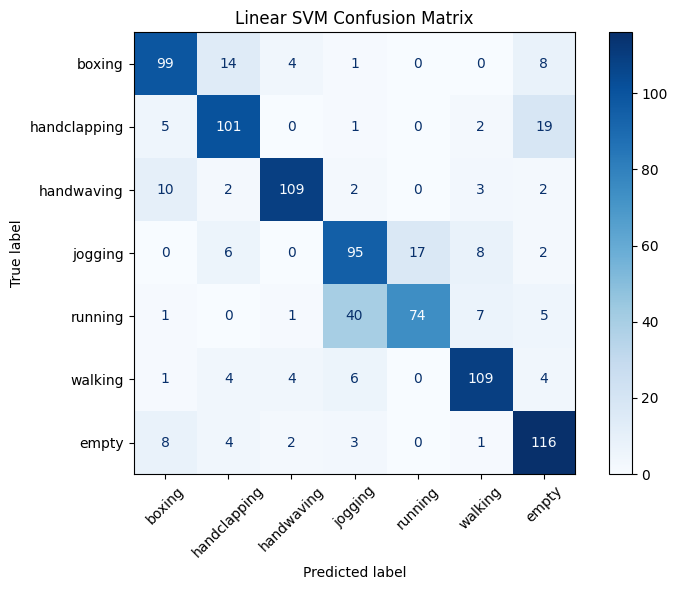

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Text
print("=== Linear SVM Confusion Matrix ===")
print(cm_svm)

# 2. Plot
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=ACTIONS)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
plt.title("Linear SVM Confusion Matrix")
plt.tight_layout()
plt.show()